In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fg = pd.read_csv("data/raw/fear_greed_index.csv")
hl = pd.read_csv("data/raw/historical_data.csv")

print("Fear/Greed shape:", fg.shape)
print("Hyperliquid shape:", hl.shape)

print("\nFear/Greed columns:", fg.columns.tolist())
print("Hyperliquid columns:", hl.columns.tolist())

display(fg.head())
display(hl.head())

Fear/Greed shape: (2644, 4)
Hyperliquid shape: (211224, 16)

Fear/Greed columns: ['timestamp', 'value', 'classification', 'date']
Hyperliquid columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Checking Data quality

In [6]:
print("=== Fear/Greed: Missing Values ===")
print(fg.isnull().sum())

print("\n=== Hyperliquid: Missing Values ===")
print(hl.isnull().sum())

print("\nFear/Greed duplicate rows:", fg.duplicated().sum())
print("Hyperliquid duplicate rows:", hl.duplicated().sum())

print("\nFear/Greed dtypes:\n", fg.dtypes)
print("\nHyperliquid dtypes:\n", hl.dtypes)

=== Fear/Greed: Missing Values ===
timestamp         0
value             0
classification    0
date              0
dtype: int64

=== Hyperliquid: Missing Values ===
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear/Greed duplicate rows: 0
Hyperliquid duplicate rows: 0

Fear/Greed dtypes:
 timestamp          int64
value              int64
classification    object
date              object
dtype: object

Hyperliquid dtypes:
 Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
C

Parse & analyse timestamps

In [8]:
hl.columns = hl.columns.str.strip()

target_col = 'time' if 'time' in hl.columns else 'timestamp'

if target_col in hl.columns:
    print(f"Using column: {target_col}")
    print("Sample values:", hl[target_col].head())
    
    hl["datetime"] = pd.to_datetime(hl[target_col], unit="ms")
    hl["date"] = hl["datetime"].dt.normalize()
    hl = hl.sort_values("datetime").reset_index(drop=True)
else:
    print("Error: Could not find 'time' or 'timestamp'. Available columns are:", hl.columns.tolist())

Error: Could not find 'time' or 'timestamp'. Available columns are: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [9]:
fg["date"] = pd.to_datetime(fg["date"])
fg = fg.sort_values("date").reset_index(drop=True)

print("Sample timestamp values:", hl["Timestamp"].head())

unit_type = "ms" if hl["Timestamp"].iloc[0] > 1e11 else "s"
print(f"Detected unit: {unit_type}")

hl["datetime"] = pd.to_datetime(hl["Timestamp"], unit=unit_type)

hl["date"] = hl["datetime"].dt.normalize()
hl = hl.sort_values("datetime").reset_index(drop=True)

print("-" * 30)
print("Fear/Greed range: ", fg["date"].min().date(), "→", fg["date"].max().date())
print("Hyperliquid range:", hl["date"].min().date(), "→", hl["date"].max().date())

Sample timestamp values: 0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64
Detected unit: ms
------------------------------
Fear/Greed range:  2018-02-01 → 2025-05-02
Hyperliquid range: 2023-03-28 → 2025-06-15


Build daily trader metrics

In [11]:
PNL_COL = "Closed PnL"

daily = (
    hl.groupby(["Account", "date"])  # Changed 'account' -> 'Account'
    .agg(
        daily_pnl        = (PNL_COL, "sum"),
        trade_count      = (PNL_COL, "count"),
        
        avg_trade_size   = ("Size USD", "mean"), 
        
        
        win_count        = (PNL_COL, lambda x: (x > 0).sum()),
        loss_count       = (PNL_COL, lambda x: (x < 0).sum()),
        
        long_count       = ("Side", lambda x: x.str.contains("Buy", case=False).sum()),
        short_count      = ("Side", lambda x: x.str.contains("Sell", case=False).sum()),
    )
    .reset_index()
)

daily["win_rate"] = daily["win_count"] / daily["trade_count"]
daily["long_short_ratio"] = (daily["long_count"] + 1) / (daily["short_count"] + 1)

print(daily.shape)
display(daily.head())

(102, 11)


,Account,date,daily_pnl,trade_count,avg_trade_size,win_count,loss_count,long_count,short_count,win_rate,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,14810.891818,12,127,139,323,0.025974,0.432099
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16345.241940,1361,232,1572,1784,0.405542,0.881232
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,2492.749906,170,0,145,175,0.531250,0.829545
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,1693.351684,1537,390,1528,2005,0.435041,0.762213
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,1533.468395,1516,553,1382,2045,0.442369,0.675953


Merge with sentiment

In [12]:
daily["date"] = pd.to_datetime(daily["date"])
fg["date"]    = pd.to_datetime(fg["date"])

sent_col = "value_classification" if "value_classification" in fg.columns else "classification"

if sent_col not in fg.columns:
    print(f"Error: Could not find sentiment column. Available: {fg.columns.tolist()}")
else:
    merged = daily.merge(fg[["date", sent_col]], on="date", how="inner")
    
    if sent_col != "classification":
        merged = merged.rename(columns={sent_col: "classification"})

    print("Merged shape:", merged.shape)
    
    if not merged.empty:
        print("Sentiment distribution:\n", merged["classification"].value_counts())
        
        try:
            merged.to_csv("merged_daily.csv", index=False)
            print("File saved successfully as 'merged_daily.csv'")
        except Exception as e:
            print(f"Could not save file: {e}")
    else:
        print("Warning: No overlapping dates found. Check if your date ranges actually match!")

Merged shape: (77, 12)
Sentiment distribution:
 classification
Greed            32
Fear             32
Neutral           8
Extreme Greed     5
Name: count, dtype: int64
File saved successfully as 'merged_daily.csv'


Sanity check

In [13]:
total_days_in_hl = daily["date"].nunique()
merged_days = merged["date"].nunique()
retention_pc = (merged_days / total_days_in_hl) * 100

print(f"Original unique days: {total_days_in_hl}")
print(f"Merged unique days:   {merged_days}")
print(f"Retention Rate:       {retention_pc:.2f}%")

if retention_pc < 100:
    missing_dates = set(daily["date"]) - set(merged["date"])
    print(f"\nExample missing dates: {list(missing_dates)[:5]}")
    print("Tip: If missing dates are very recent, the Fear/Greed API might not have updated yet.")

hl["datetime"] = pd.to_datetime(hl["Timestamp"], unit=unit_type).dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata')

Original unique days: 7
Merged unique days:   6
Retention Rate:       85.71%

Example missing dates: [Timestamp('2025-06-15 00:00:00')]
Tip: If missing dates are very recent, the Fear/Greed API might not have updated yet.


PnL and win rate: Fear vs Greed

,daily_pnl_mean,daily_pnl_median,daily_pnl_std,win_rate_mean,win_rate_median,win_rate_std,trade_count_mean,trade_count_median,trade_count_std
classification,,,,,,,,,
Extreme Greed,35393.098355,0.000000,85325.499902,0.336609,0.306849,0.302367,1392.40000,730.0,1545.715142
Fear,209372.662205,81389.682515,380423.906864,0.415878,0.393962,0.136967,4183.46875,2763.5,5730.675437
Greed,99675.516731,35988.376437,282694.285526,0.374074,0.412599,0.277185,1134.03125,275.0,2139.809616
Neutral,19842.797260,-0.418640,57227.787895,0.260683,0.188324,0.307062,892.62500,164.5,1342.959306


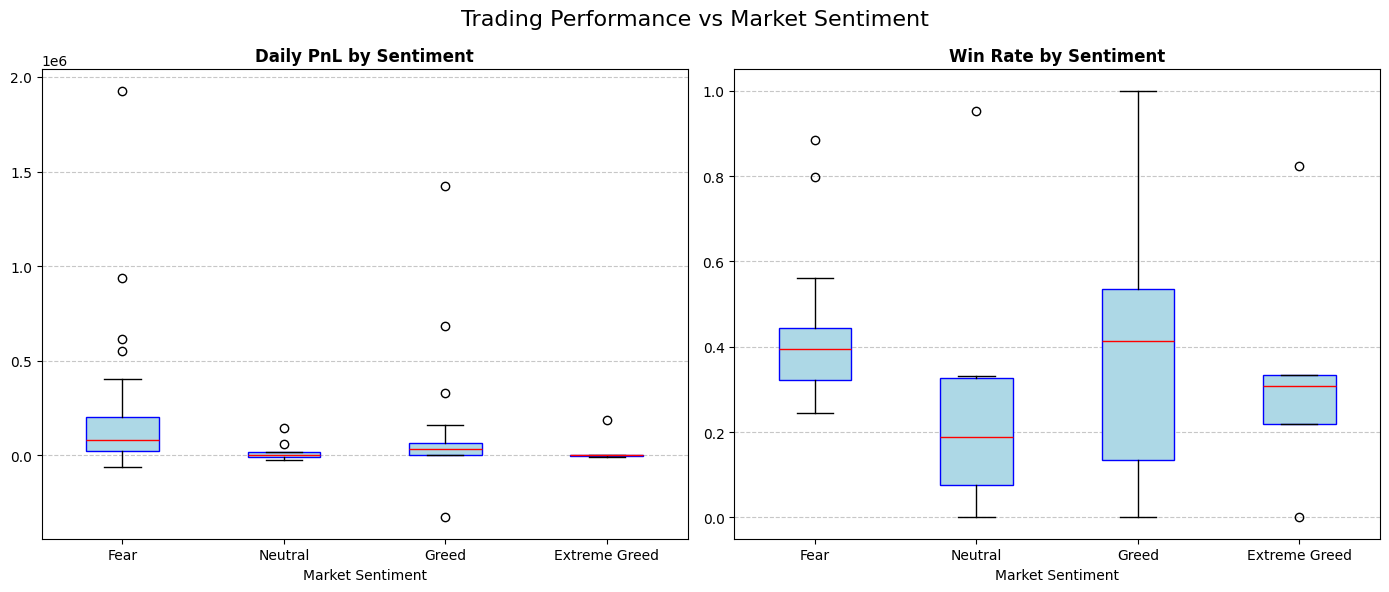

In [14]:
import matplotlib.pyplot as plt

target_cols = ["daily_pnl", "win_rate", "trade_count"]

sentiment_stats = (
    merged.groupby("classification")[target_cols]
    .agg(["mean", "median", "std"])
)

sentiment_stats.columns = ['_'.join(col).strip() for col in sentiment_stats.columns.values]

display(sentiment_stats)

try:
    sentiment_stats.to_csv("sentiment_stats.csv")
except:
    sentiment_stats.to_csv("sentiment_stats.csv")

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
existing_order = [s for s in sentiment_order if s in merged["classification"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(
    axes,
    ["daily_pnl", "win_rate"],
    ["Daily PnL by Sentiment", "Win Rate by Sentiment"]
):
    data_to_plot = [merged[merged["classification"] == s][col].dropna() for s in existing_order]
    
    ax.boxplot(data_to_plot, patch_artist=True, 
               boxprops=dict(facecolor="lightblue", color="blue"),
               medianprops=dict(color="red"))
    
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(existing_order)
    ax.set_xlabel("Market Sentiment")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Trading Performance vs Market Sentiment", fontsize=16)
plt.tight_layout()

plt.savefig("pnl_winrate_by_sentiment.png", dpi=150)
plt.show()

In [15]:
from scipy import stats

fear_pnl  = merged.loc[merged["classification"] == "Fear",  "daily_pnl"]
greed_pnl = merged.loc[merged["classification"] == "Greed", "daily_pnl"]

t_stat, p_value = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")
print(f"Mann-Whitney U test: statistic={t_stat:.2f}, p={p_value:.4f}")


Mann-Whitney U test: statistic=669.00, p=0.0356


Behavior changes by sentiment

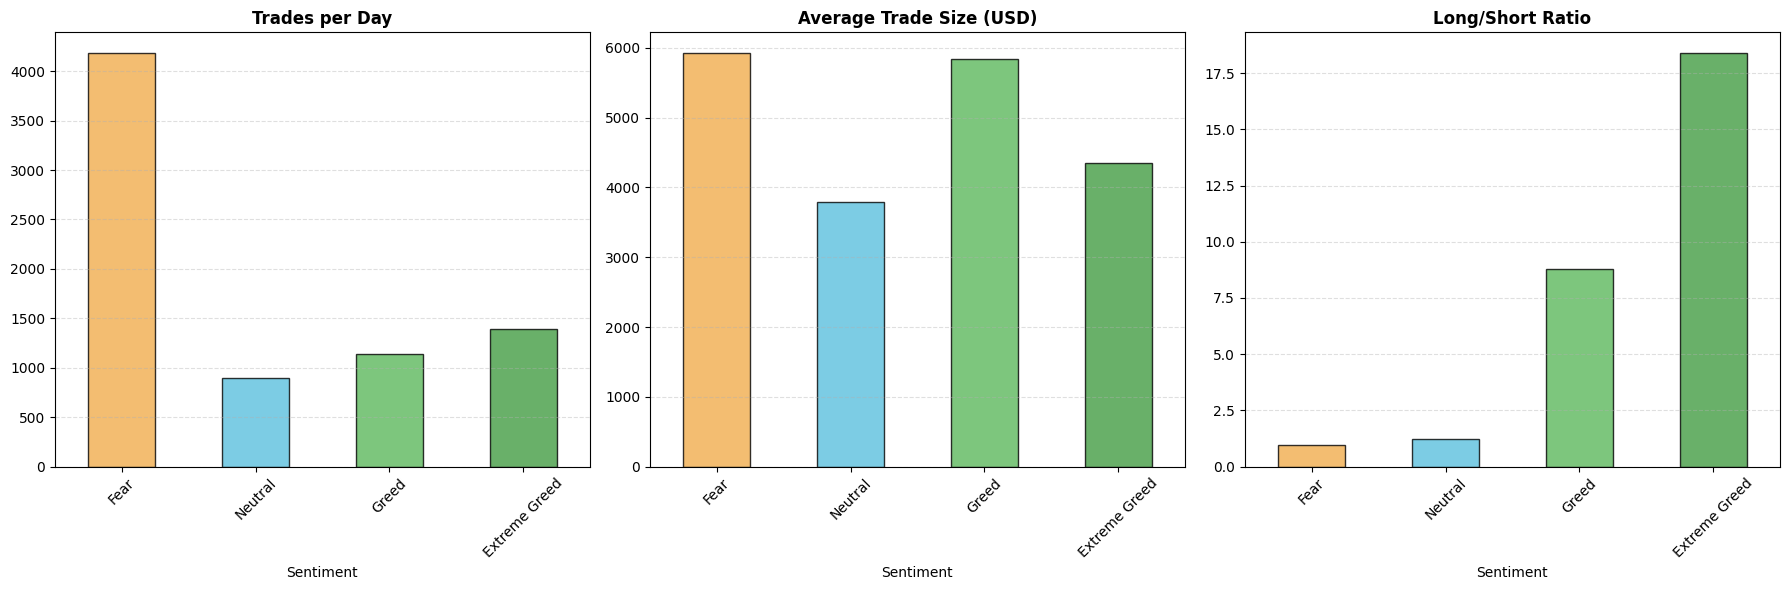

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiment_colors = {
    "Extreme Fear": "#d9534f", # Red
    "Fear": "#f0ad4e",         # Orange
    "Neutral": "#5bc0de",      # Blue/Grey
    "Greed": "#5cb85c",        # Green
    "Extreme Greed": "#449d44" # Dark Green
}

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
existing_order = [s for s in sentiment_order if s in merged["classification"].unique()]
colors = [sentiment_colors[s] for s in existing_order]

metrics = ["trade_count", "avg_trade_size", "long_short_ratio"]
titles = ["Trades per Day", "Average Trade Size (USD)", "Long/Short Ratio"]

for ax, col, title in zip(axes, metrics, titles):
    stats = merged.groupby("classification")[col].mean().reindex(existing_order)
    stats.plot(kind="bar", ax=ax, color=colors, edgecolor='black', alpha=0.8)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Sentiment")
    ax.tick_params(axis="x", rotation=45) # Rotated for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("behavior_by_sentiment.png", dpi=150)
plt.show()

Segment traders

In [17]:
import numpy as np

account_stats = (
    merged.groupby("Account")  # Capitalized 'A' to match your data
    .agg(
        total_pnl      = ("daily_pnl", "sum"),
        avg_trade_size = ("avg_trade_size", "mean"), 
        total_trades   = ("trade_count", "sum"),
        avg_win_rate   = ("win_rate", "mean"),
        days_active    = ("date", "count"),
    )
    .reset_index()
)

size_median = account_stats["avg_trade_size"].median()
account_stats["risk_segment"] = np.where(
    account_stats["avg_trade_size"] >= size_median, "Large Sizes", "Small Sizes"
)

freq_median = account_stats["days_active"].median()
account_stats["freq_segment"] = np.where(
    account_stats["days_active"] >= freq_median, "Frequent", "Infrequent"
)

account_stats["winner_segment"] = np.where(
    (account_stats["avg_win_rate"] >= 0.50) & (account_stats["total_pnl"] > 0),
    "Consistent Winner", "Other"
)

display(account_stats.sort_values("total_pnl", ascending=False).head(10))

account_stats.to_csv("account_segments.csv", index=False)

,Account,total_pnl,avg_trade_size,total_trades,avg_win_rate,days_active,risk_segment,freq_segment,winner_segment
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.040922e+06,5106.900184,14410,0.332406,5,Large Sizes,Frequent,Other
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,15578.066879,3818,0.215758,2,Large Sizes,Frequent,Other
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401572e+05,3210.775186,21190,0.467532,1,Small Sizes,Infrequent,Other
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.111830e+05,2124.060565,36534,0.477062,2,Small Sizes,Frequent,Other
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.744040e+05,8721.255131,4134,0.453428,2,Large Sizes,Frequent,Other
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.258152e+05,12204.608594,1134,0.477383,2,Large Sizes,Frequent,Other
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,3111.662097,1051,0.579597,4,Small Sizes,Frequent,Consistent Winner
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,4.035016e+05,15783.011971,6000,0.207807,2,Large Sizes,Frequent,Other
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.936830e+05,2214.300348,1358,0.212403,2,Small Sizes,Frequent,Other
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.615766e+05,2024.855107,8948,0.652543,4,Small Sizes,Frequent,Consistent Winner


classification,Fear,Neutral,Greed,Extreme Greed
risk_segment,,,,
Large Sizes,278058.006946,9202.357515,100204.801639,-3625.530805
Small Sizes,140687.317465,30483.237005,99075.660501,93921.042095


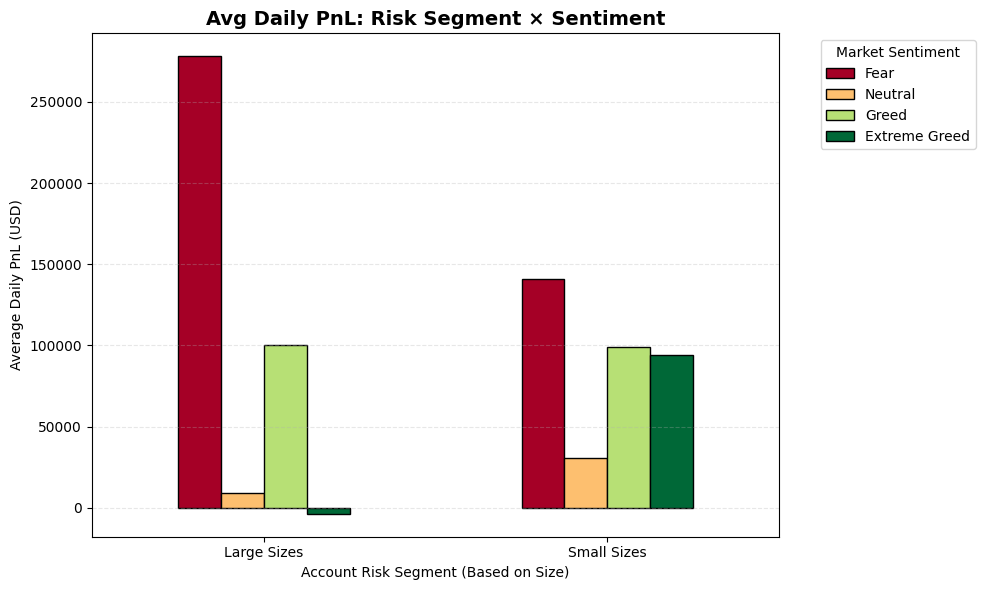

In [18]:
merged2 = merged.merge(
    account_stats[["Account", "risk_segment", "freq_segment", "winner_segment"]],
    on="Account", 
    how="left"
)

pivot = (
    merged2.groupby(["risk_segment", "classification"])["daily_pnl"]
    .mean()
    .unstack()
)

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
existing_cols = [s for s in sentiment_order if s in pivot.columns]
pivot = pivot[existing_cols]

display(pivot)

ax = pivot.plot(
    kind="bar", 
    figsize=(10, 6), 
    colormap="RdYlGn", # Red-Yellow-Green fits the sentiment vibe
    edgecolor="black"
)

plt.title("Avg Daily PnL: Risk Segment × Sentiment", fontweight='bold', fontsize=14)
plt.ylabel("Average Daily PnL (USD)")
plt.xlabel("Account Risk Segment (Based on Size)")
plt.xticks(rotation=0)
plt.legend(title="Market Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("segment_sentiment_pnl.png", dpi=150)
plt.show()

Chart 1 — Heatmap: Avg PnL by Weekday × Sentiment

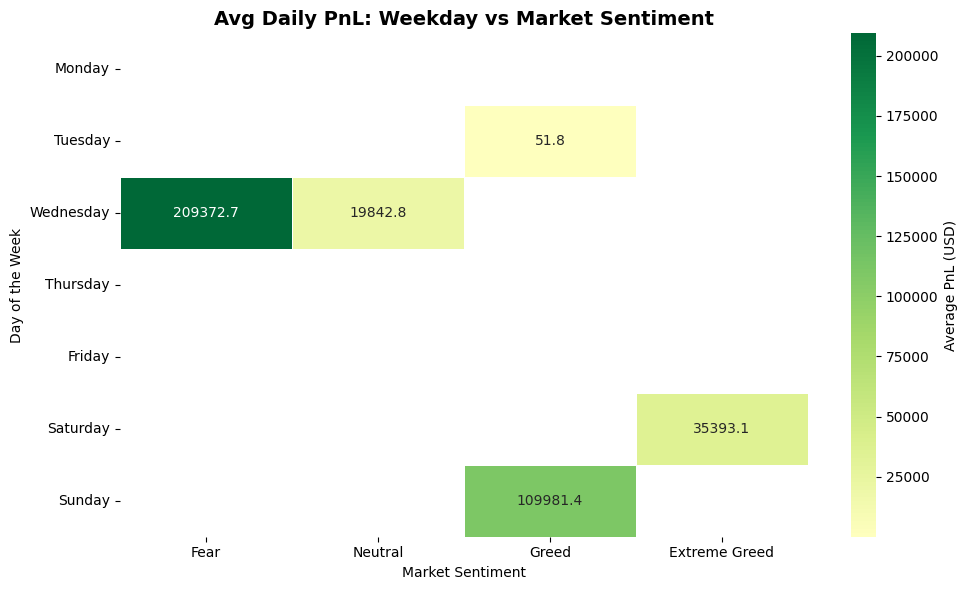

In [19]:
merged2["weekday"] = pd.to_datetime(merged2["date"]).dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heat = merged2.groupby(["weekday", "classification"])["daily_pnl"].mean().unstack()

heat = heat.reindex(day_order)

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
existing_sentiment = [s for s in sentiment_order if s in heat.columns]
heat = heat[existing_sentiment]

plt.figure(figsize=(10, 6))

sns.heatmap(
    heat, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Average PnL (USD)'}
)

plt.title("Avg Daily PnL: Weekday vs Market Sentiment", fontweight='bold', fontsize=14)
plt.xlabel("Market Sentiment")
plt.ylabel("Day of the Week")

plt.tight_layout()
plt.savefig("heatmap_weekday_sentiment.png", dpi=150)
plt.show()

Chart 2 — Time series: Rolling PnL overlaid with sentiment

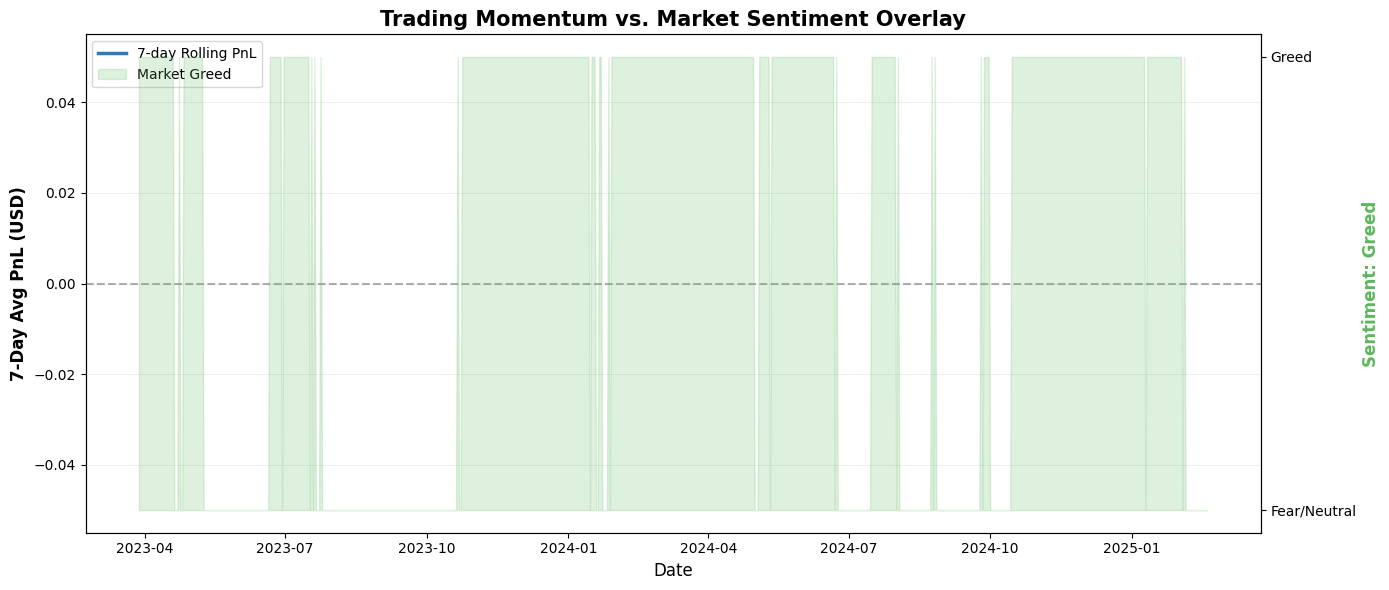

In [20]:
daily_totals = merged2.groupby("date")["daily_pnl"].sum().reset_index()
daily_totals = daily_totals.sort_values("date")
daily_totals["rolling_pnl"] = daily_totals["daily_pnl"].rolling(7).mean()

start_date = daily_totals["date"].min()
end_date = daily_totals["date"].max()
mask = (fg["date"] >= start_date) & (fg["date"] <= end_date)
daily_fg = fg.loc[mask].copy().sort_values("date")

daily_fg["is_greed"] = daily_fg["classification"].str.contains("Greed").astype(int)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(daily_totals["date"], daily_totals["rolling_pnl"], 
         color="#2c7bb6", linewidth=2.5, label="7-day Rolling PnL")
ax1.axhline(0, color="black", linestyle="--", alpha=0.3) # Zero line for PnL reference
ax1.set_ylabel("7-Day Avg PnL (USD)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Date", fontsize=12)

ax2 = ax1.twinx()
ax2.fill_between(daily_fg["date"], 0, daily_fg["is_greed"], 
                 alpha=0.2, color="#5cb85c", label="Market Greed")
ax2.set_ylabel("Sentiment: Greed", color="#5cb85c", fontsize=12, fontweight='bold')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Fear/Neutral", "Greed"])

ax1.set_title("Trading Momentum vs. Market Sentiment Overlay", fontsize=15, fontweight='bold')
ax1.grid(axis='y', alpha=0.2)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("timeseries_pnl_sentiment.png", dpi=150)
plt.show()

Chart 3 — Leverage distribution: Fear vs Greed

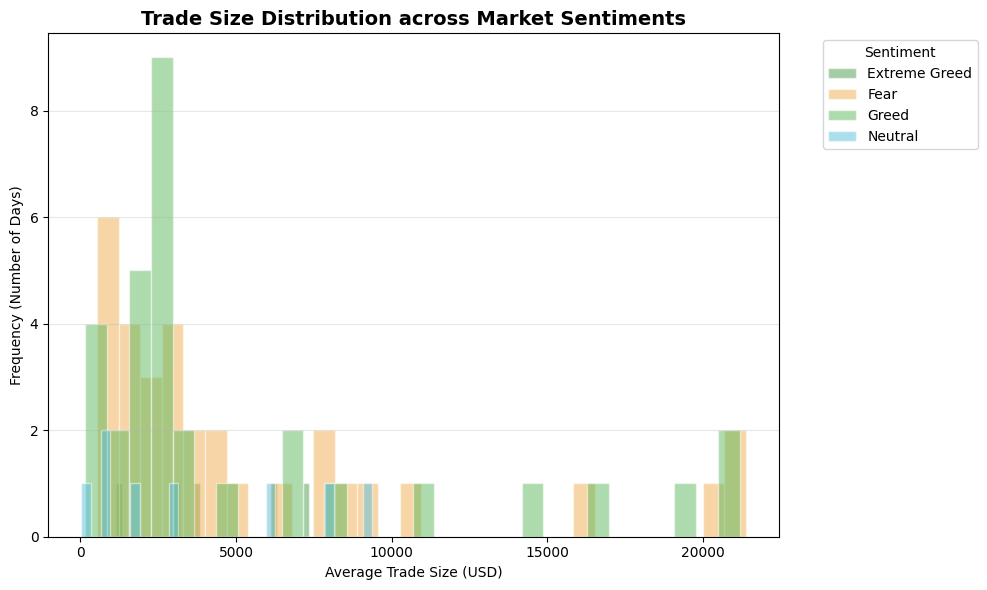

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sentiment_colors = {
    "Extreme Fear": "#d9534f", # Red
    "Fear": "#f0ad4e",         # Orange
    "Neutral": "#5bc0de",      # Blue
    "Greed": "#5cb85c",        # Green
    "Extreme Greed": "#4c9d4c" # Dark Green
}

for label, grp in merged2.groupby("classification"):
    upper_limit = grp["avg_trade_size"].quantile(0.95) # Clip at 95th percentile
    
    grp["avg_trade_size"].clip(upper=upper_limit).plot.hist(
        bins=30, 
        alpha=0.5, 
        ax=ax, 
        label=label,
        color=sentiment_colors.get(label, "grey"),
        edgecolor='white'
    )

ax.set_title("Trade Size Distribution across Market Sentiments", fontweight='bold', fontsize=14)
ax.set_xlabel("Average Trade Size (USD)")
ax.set_ylabel("Frequency (Number of Days)")

ax.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig("trade_size_distribution.png", dpi=150)
plt.show()

try a predictive model

Model Performance on Test Data:
----------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.83      0.91      0.87        11

    accuracy                           0.81        16
   macro avg       0.79      0.75      0.77        16
weighted avg       0.81      0.81      0.81        16



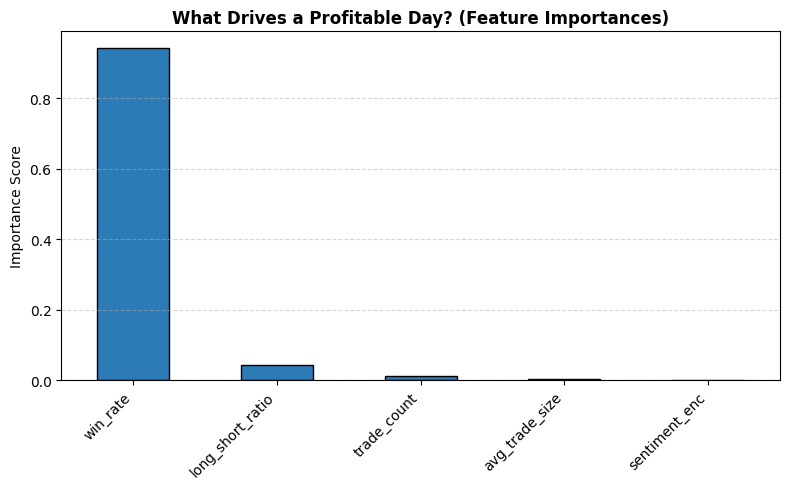

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

features = ["avg_trade_size", "trade_count", "win_rate", "long_short_ratio"]
target = "profitable"   # 1 if daily_pnl > 0, else 0

model_df = merged2[features + ["classification", "daily_pnl"]].dropna().copy()

model_df["sentiment_enc"] = (model_df["classification"].str.contains("Greed", na=False)).astype(int)

model_df[target] = (model_df["daily_pnl"] > 0).astype(int)

X = model_df[features + ["sentiment_enc"]]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print("Model Performance on Test Data:")
print("-" * 40)
print(classification_report(y_test, clf.predict(X_test)))

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar", color="#2c7bb6", edgecolor="black")
plt.title("What Drives a Profitable Day? (Feature Importances)", fontweight='bold')
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

Trade Clustering

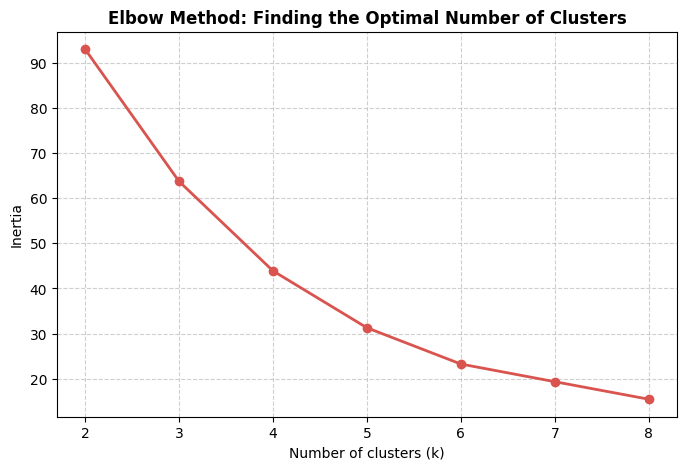


--- Performance Profiles for 4 Strategy Clusters ---


,total_pnl,avg_trade_size,total_trades,avg_win_rate
cluster,,,,
0.0,1.282314e+05,2735.804560,3403.454545,0.503826
1.0,1.264088e+06,3480.578645,24044.666667,0.425667
2.0,1.420865e+05,3230.423759,4194.727273,0.252582
3.0,4.942129e+05,15029.330778,4078.428571,0.363249


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cluster_features = ["total_pnl", "avg_trade_size", "total_trades", "avg_win_rate"]

X_clust = account_stats[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="#d9534f", linewidth=2)
plt.title("Elbow Method: Finding the Optimal Number of Clusters", fontweight='bold')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("elbow_method.png", dpi=150)
plt.show()

CHOSEN_K = 4
km = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)

account_stats.loc[X_clust.index, "cluster"] = km.fit_predict(X_scaled)

print(f"\n--- Performance Profiles for {CHOSEN_K} Strategy Clusters ---")
cluster_summary = account_stats.groupby("cluster")[cluster_features].mean()
display(cluster_summary)

account_stats.to_csv("account_segments_with_clusters.csv", index=False)

In [1]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Trader Analytics", layout="wide")
st.title("📈 Trader Behavior vs Market Sentiment")

try:
    merged = pd.read_csv("merged_daily.csv", parse_dates=["date"])
except FileNotFoundError:
    st.error("Could not find 'merged_daily.csv'. Please run the processing script first.")
    st.stop()

st.sidebar.header("Global Filters")
sentiment_list = ["All"] + sorted(merged["classification"].unique().tolist())
sentiment = st.sidebar.selectbox("Filter by Market Sentiment", sentiment_list)

if sentiment != "All":
    filtered_df = merged[merged["classification"] == sentiment]
else:
    filtered_df = merged

col1, col2 = st.columns(2)

with col1:
    st.subheader("💰 PnL Distribution")
    fig = px.histogram(
        filtered_df, 
        x="daily_pnl", 
        color="classification",
        barmode="overlay", 
        nbins=50,
        labels={"daily_pnl": "Daily PnL (USD)", "classification": "Sentiment"},
        color_discrete_map={"Fear": "#ef553b", "Greed": "#00cc96", "Neutral": "#636efa"}
    )
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("⚖️ Risk vs Win Rate")
    fig2 = px.scatter(
        filtered_df, 
        x="avg_trade_size", 
        y="win_rate",
        color="classification", 
        size="trade_count", # Larger bubbles = more active days
        opacity=0.6,
        labels={"avg_trade_size": "Average Trade Size (USD)", "win_rate": "Win Rate"},
        hover_data=["date", "trade_count"]
    )
    st.plotly_chart(fig2, use_container_width=True)

st.subheader("📋 Raw Daily Data")
st.dataframe(filtered_df.sort_values("date", ascending=False), use_container_width=True)

2026-03-14 01:57:39.834 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 01:57:39.835 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 01:57:40.097 
  command:

    streamlit run c:\Users\paulr\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-14 01:57:40.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 01:57:40.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 01:57:40.123 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 01:57:40.124 Thread 'MainThread': missing ScriptRunContext! This wa

DeltaGenerator()

Author: Rounak Paul, DAte 14.03.26, Asansol, Time 1:35 Am